# Semiconductor Wafer Yield Analysis
이 노트북에서는 업로드된 `csv` 파일을 이용해 웨이퍼 수율을 계산하고, EDA 및 분류 모델링을 수행합니다.

1. 환경 설정 및 라이브러리 Import

In [30]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## 2. 데이터 로드

In [31]:
import os
import pandas as pd

folder_path = r"..\wafer\csv"
csv_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.csv')]

# 각 CSV 파일을 읽어들여 딕셔너리에 저장 (key: 파일명, value: DataFrame)
dfs = {}
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    dfs[file] = pd.read_csv(file_path)

print("CSV 파일 로드 완료:", list(dfs.keys()))

CSV 파일 로드 완료: ['validation_features_only.csv', 'wafer01.csv', 'wafer02.csv', 'wafer03.csv', 'wafer04.csv', 'wafer05.csv', 'wafer06.csv', 'wafer07.csv', 'wafer08.csv', 'wafer09.csv', 'wafer10.csv', 'wafer11.csv', 'wafer12.csv', 'wafer13.csv', 'wafer14.csv', 'wafer15.csv', 'wafer16.csv', 'wafer17.csv', 'wafer18.csv', 'wafer19.csv', 'wafer20.csv']


## 3. 데이터 구조 확인

In [32]:
for file_name, df in dfs.items():
    print(f"\n===== {file_name} 데이터프레임 정보 =====")
    df.info()
    
    print(f"\n----- {file_name} 기술 통계 (수치형 및 범주형) -----")
    print(df.describe(include='all'))
    
    print(f"\n----- {file_name} 각 컬럼별 결측치 수 -----")
    print(df.isnull().sum())


===== validation_features_only.csv 데이터프레임 정보 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Columns: 443 entries, ID to TTV
dtypes: float64(442), int64(1)
memory usage: 69.3 KB

----- validation_features_only.csv 기술 통계 (수치형 및 범주형) -----
             ID    Sensor-1    Sensor-2    Sensor-3    Sensor-4    Sensor-5  \
count  20.00000   20.000000   20.000000   20.000000   20.000000   20.000000   
mean   10.50000  109.791869  110.759434  110.254109  110.171682  110.289276   
std     5.91608    4.674112    4.036210    3.974658    4.045796    4.431406   
min     1.00000  101.428169  101.554858  103.177063  101.671363  101.982248   
25%     5.75000  108.252047  110.811949  110.048005  110.373538  110.415869   
50%    10.50000  111.122247  111.659502  111.317275  111.324943  111.293412   
75%    15.25000  112.324292  112.431773  111.929373  112.380596  112.305498   
max    20.00000  119.710885  119.431395  118.687922  117.455702  120.139214   

         Sensor-6    

In [33]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns.tolist())

['id', 'sensor-1', 'sensor-2', 'sensor-3', 'sensor-4', 'sensor-5', 'sensor-6', 'sensor-7', 'sensor-8', 'sensor-9', 'sensor-10', 'sensor-11', 'sensor-12', 'sensor-13', 'sensor-14', 'sensor-15', 'sensor-16', 'sensor-17', 'sensor-18', 'sensor-19', 'sensor-20', 'sensor-21', 'sensor-22', 'sensor-23', 'sensor-24', 'sensor-25', 'sensor-26', 'sensor-27', 'sensor-28', 'sensor-29', 'sensor-30', 'sensor-31', 'sensor-32', 'sensor-33', 'sensor-34', 'sensor-35', 'sensor-36', 'sensor-37', 'sensor-38', 'sensor-39', 'sensor-40', 'sensor-41', 'sensor-42', 'sensor-43', 'sensor-44', 'sensor-45', 'sensor-46', 'sensor-47', 'sensor-48', 'sensor-49', 'sensor-50', 'sensor-51', 'sensor-52', 'sensor-53', 'sensor-54', 'sensor-55', 'sensor-56', 'sensor-57', 'sensor-58', 'sensor-59', 'sensor-60', 'sensor-61', 'sensor-62', 'sensor-63', 'sensor-64', 'sensor-65', 'sensor-66', 'sensor-67', 'sensor-68', 'sensor-69', 'sensor-70', 'sensor-71', 'sensor-72', 'sensor-73', 'sensor-74', 'sensor-75', 'sensor-76', 'sensor-77', '

In [34]:
import pandas as pd

# 파일 읽기
df = pd.read_csv(r'..\wafer\csv\validation_features_only.csv') # wafer01~20

# 상위 10개 행 미리보기
print(df.head(2))

   ID    Sensor-1    Sensor-2    Sensor-3    Sensor-4    Sensor-5    Sensor-6  \
0   1  110.117117  112.552679  110.675964  112.593944  111.138116  110.465503   
1   2  113.345655  110.195905  111.496844  110.803869  112.963709  110.844876   

     Sensor-7    Sensor-8    Sensor-9  ...  Sensor-433  Sensor-434  \
0  111.989286  111.780392  111.597217  ...  111.719585  110.603941   
1  111.735879  111.168811  111.994109  ...  111.939380  112.181702   

   Sensor-435  Sensor-436  Sensor-437  Sensor-438  Sensor-439  Sensor-440  \
0  112.845593  111.019321  112.928894  103.325799  112.818036  111.421745   
1  113.625204  112.529801  112.689592  111.299126  112.657734  113.253485   

   Sensor-441        TTV  
0  111.639156  12.391837  
1  113.006238  12.957992  

[2 rows x 443 columns]


In [35]:
print("컬럼명 목록:", df.columns.tolist())
for col in df.columns:
    print(f"\n[{col}] 고유값:")
    print(df[col].unique())

컬럼명 목록: ['ID', 'Sensor-1', 'Sensor-2', 'Sensor-3', 'Sensor-4', 'Sensor-5', 'Sensor-6', 'Sensor-7', 'Sensor-8', 'Sensor-9', 'Sensor-10', 'Sensor-11', 'Sensor-12', 'Sensor-13', 'Sensor-14', 'Sensor-15', 'Sensor-16', 'Sensor-17', 'Sensor-18', 'Sensor-19', 'Sensor-20', 'Sensor-21', 'Sensor-22', 'Sensor-23', 'Sensor-24', 'Sensor-25', 'Sensor-26', 'Sensor-27', 'Sensor-28', 'Sensor-29', 'Sensor-30', 'Sensor-31', 'Sensor-32', 'Sensor-33', 'Sensor-34', 'Sensor-35', 'Sensor-36', 'Sensor-37', 'Sensor-38', 'Sensor-39', 'Sensor-40', 'Sensor-41', 'Sensor-42', 'Sensor-43', 'Sensor-44', 'Sensor-45', 'Sensor-46', 'Sensor-47', 'Sensor-48', 'Sensor-49', 'Sensor-50', 'Sensor-51', 'Sensor-52', 'Sensor-53', 'Sensor-54', 'Sensor-55', 'Sensor-56', 'Sensor-57', 'Sensor-58', 'Sensor-59', 'Sensor-60', 'Sensor-61', 'Sensor-62', 'Sensor-63', 'Sensor-64', 'Sensor-65', 'Sensor-66', 'Sensor-67', 'Sensor-68', 'Sensor-69', 'Sensor-70', 'Sensor-71', 'Sensor-72', 'Sensor-73', 'Sensor-74', 'Sensor-75', 'Sensor-76', 'Senso

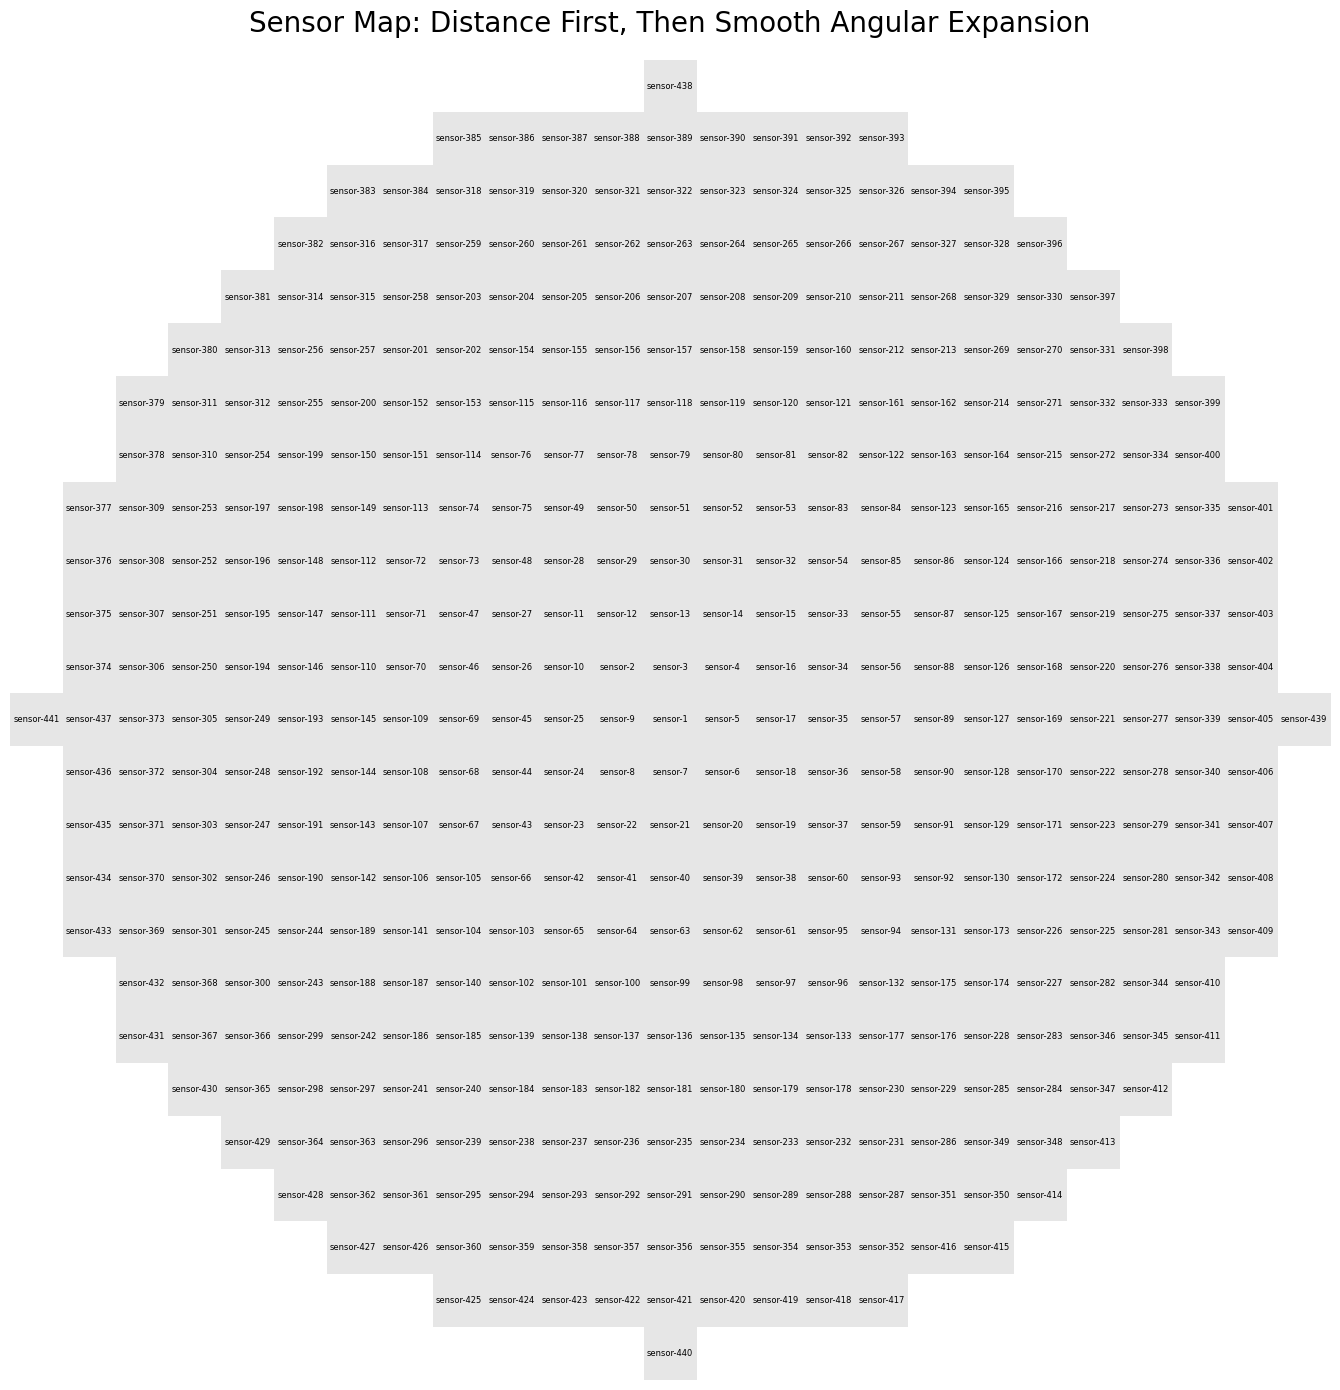

In [36]:
# 거리 우선 정렬 후, 각 거리 구간 내에서 점진적으로 각도 순서를 반영한 정렬 수행

from collections import defaultdict

# 거리(r)의 정수값을 기준으로 계층화
layered_coords = defaultdict(list)
for coord in coords:
    r = int(np.linalg.norm(np.array(coord) - center))
    layered_coords[r].append(coord)

# 거리 순으로 레이어 순회하면서 각도 기준 정렬
final_sorted_coords = []
for r in sorted(layered_coords.keys()):
    layer = layered_coords[r]
    sorted_layer = sorted(layer, key=lambda c: np.arctan2(c[0] - center_y, c[1] - center_x))
    final_sorted_coords.extend(sorted_layer)

# 센서 이름 생성 및 배치
sensor_map = np.full((rows, cols), '', dtype=object)
for idx, (i, j) in enumerate(final_sorted_coords):
    sensor_map[i, j] = f"sensor-{idx + 1}"

# 시각화
plt.figure(figsize=(14, 14))
plt.imshow(mask, cmap='Greys', alpha=0.1)
plt.title("Sensor Map: Distance First, Then Smooth Angular Expansion", fontsize=20, pad=20)

for i in range(rows):
    for j in range(cols):
        if sensor_map[i, j]:
            plt.text(j, i, sensor_map[i, j], ha='center', va='center', fontsize=6)

plt.axis('off')
plt.tight_layout()
plt.show()


# 전처리 df 칼럼 생성

In [37]:
# 컬럼명 전처리(공백 제거, 소문자 통일)
df.columns = df.columns.str.strip().str.lower()

# 센서 컬럼 추출 (sensor-로 시작)
sensor_cols = [col for col in df.columns if col.startswith('sensor-')]

# 센서 번호 기준으로 정렬
import re
def sensor_num(col):
    m = re.match(r'sensor-(\d+)', col)
    return int(m.group(1)) if m else 9999
sensor_cols = sorted(sensor_cols, key=sensor_num)

print(sensor_cols[:10])  # 앞부분 확인
print(sensor_cols[-10:]) # 뒷부분 확인

['sensor-1', 'sensor-2', 'sensor-3', 'sensor-4', 'sensor-5', 'sensor-6', 'sensor-7', 'sensor-8', 'sensor-9', 'sensor-10']
['sensor-432', 'sensor-433', 'sensor-434', 'sensor-435', 'sensor-436', 'sensor-437', 'sensor-438', 'sensor-439', 'sensor-440', 'sensor-441']


# 데이터셋 대로 웨이퍼 생성

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import re
from matplotlib.colors import LinearSegmentedColormap
from collections import defaultdict

rows, cols = 25, 25
sensor_shape = (rows, cols)
yy, xx = np.ogrid[:rows, :cols]
center_y, center_x = (rows - 1) / 2, (cols - 1) / 2
radius = min(center_y, center_x)
mask = (yy - center_y)**2 + (xx - center_x)**2 <= radius**2
center = np.array([center_y, center_x])


In [39]:
coords = list(zip(*np.where(mask)))
layered_coords = defaultdict(list)
for coord in coords:
    r = int(np.linalg.norm(np.array(coord) - center))
    layered_coords[r].append(coord)

final_sorted_coords = []
for r in sorted(layered_coords.keys()):
    layer = layered_coords[r]
    sorted_layer = sorted(layer, key=lambda c: np.arctan2(c[0] - center_y, c[1] - center_x))
    final_sorted_coords.extend(sorted_layer)


In [40]:
df.columns = df.columns.str.strip().str.lower()
def sensor_num(col):
    m = re.match(r'sensor-0*(\d+)', col)
    return int(m.group(1)) if m else 9999

sensor_cols = [col for col in df.columns if col.startswith('sensor-')]
sensor_cols = sorted(sensor_cols, key=sensor_num)
sensor_cols = sensor_cols[:len(final_sorted_coords)]


In [41]:
def fill_nan_with_neighbors(arr, mask):
    filled = arr.copy()
    nan_mask = np.isnan(arr)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            if nan_mask[i, j] and not mask[i, j]:
                neighbors = []
                for di in [-1, 0, 1]:
                    for dj in [-1, 0, 1]:
                        ni, nj = i + di, j + dj
                        if 0 <= ni < arr.shape[0] and 0 <= nj < arr.shape[1]:
                            if not np.isnan(arr[ni, nj]):
                                neighbors.append(arr[ni, nj])
                if neighbors:
                    filled[i, j] = np.mean(neighbors)
    return filled


In [42]:
# defect_wafer_ids = []

# for idx, row in df.iterrows():
#     wafer_id = row.get('unnamed: 0', f'Wafer_{idx + 1}')
#     sensor_values = pd.to_numeric(row[sensor_cols], errors='coerce').values

#     sensor_map = np.full(sensor_shape, np.nan)
#     for i, (y, x) in enumerate(final_sorted_coords):
#         if i < len(sensor_values):
#             sensor_map[y, x] = sensor_values[i]

#     normal_sensor = ((sensor_map >= 109) & (sensor_map <= 115))
#     normal_count = np.count_nonzero(normal_sensor)
#     total_sensor = np.count_nonzero(~np.isnan(sensor_map))
#     wafer_yield = normal_count / total_sensor * 100 if total_sensor > 0 else 0

#     max_val = np.nanmax(sensor_map)
#     min_val = np.nanmin(sensor_map)
#     mean_val = np.nanmean(sensor_map)
#     ttv = max_val - min_val

#     defect_reasons = []
#     if ttv > 7:
#         defect_reasons.append('TTV>7')
#     if wafer_yield < 80:
#         defect_reasons.append('yield<80')
#     if max_val >= 117:
#         defect_reasons.append('max>=117')
#     if min_val < 105:
#         defect_reasons.append('min<105')
#     if mean_val >= 113.0 or mean_val < 111.0:
#         defect_reasons.append('mean!=112')

#     if defect_reasons:
#         defect_label = 'defect, ' + ', '.join(defect_reasons)
#     else:
#         defect_label = 'normal'

#     if defect_label == 'defect':
#         defect_wafer_ids.append((wafer_id, defect_label))

#     filled_map = fill_nan_with_neighbors(sensor_map, ~mask)
#     cmap = LinearSegmentedColormap.from_list('custom', [
#         (0, (120/255, 180/255, 255/255)),
#         (0.2, (0, 1, 1)),
#         (0.4, (0.5, 1, 0.5)),
#         (0.6, (1, 1, 0)),
#         (0.8, (1, 0, 0)),
#         (1.0, (0.5, 0, 0))
#     ])

#     plt.figure(figsize=(8, 8))
#     im = plt.imshow(np.ma.masked_where(~mask, filled_map), cmap=cmap, vmin=80, vmax=130)
#     title = (
#         f'{wafer_id} | Yield: {wafer_yield:.2f}% | {defect_label}\n'
#         f'Max: {max_val:.1f}, Min: {min_val:.1f}, Mean: {mean_val:.1f}, TTV: {ttv:.1f}'
#     )
#     plt.title(title, fontsize=14)
#     plt.colorbar(im, label='Sensor Value')

#     for i in range(rows):
#         for j in range(cols):
#             if mask[i, j]:
#                 val = sensor_map[i, j]
#                 text_color = 'blue' if np.isnan(val) else 'black'
#                 text_val = f'{filled_map[i, j]:.0f}' if np.isnan(val) else f'{int(val)}'
#                 plt.text(j, i, text_val, ha='center', va='center', fontsize=6, color=text_color)

#     plt.axis('off')
#     plt.tight_layout()
#     plt.show()


In [43]:
defect_count = 0
normal_count = 0
yield_sum = 0
wafer_cnt = 0

for idx, row in df.iterrows():
    wafer_id = row.get('unnamed: 0', f'Wafer_{idx + 1}')
    sensor_values = pd.to_numeric(row[sensor_cols], errors='coerce').values

    sensor_map = np.full(sensor_shape, np.nan)
    for i, (y, x) in enumerate(final_sorted_coords):
        if i < len(sensor_values):
            sensor_map[y, x] = sensor_values[i]

    # 정상 범위 센서값 개수로 수율 계산
    normal_sensor = ((sensor_map >= 109) & (sensor_map <= 115))
    normal_count_per_wafer = np.count_nonzero(normal_sensor)
    total_sensor = np.count_nonzero(~np.isnan(sensor_map))
    wafer_yield = normal_count_per_wafer / total_sensor * 100 if total_sensor > 0 else 0

    yield_sum += wafer_yield
    wafer_cnt += 1

    max_val = np.nanmax(sensor_map)
    min_val = np.nanmin(sensor_map)
    mean_val = np.nanmean(sensor_map)
    ttv = max_val - min_val

    if ttv > 7:
        defect_label = 'defect'
    else:
        count = 0
        if max_val >= 120:
            count += 1
        if min_val < 90:
            count += 1
        if mean_val < 100:
            count += 1
        defect_label = 'defect' if count >= 3 else 'normal'

    if defect_label == 'defect':
        defect_count += 1
    else:
        normal_count += 1

total = defect_count + normal_count
yield_rate = normal_count / total * 100 if total > 0 else 0
mean_yield = yield_sum / wafer_cnt if wafer_cnt > 0 else 0

print(f"defect 웨이퍼: {defect_count}장")
print(f"normal 웨이퍼: {normal_count}장")
print(f"전체 웨이퍼: {total}장")
print(f"전체 yield(수율): {yield_rate:.2f}%")
print(f"평균 yield(평균 수율): {mean_yield:.2f}%")

defect 웨이퍼: 19장
normal 웨이퍼: 1장
전체 웨이퍼: 20장
전체 yield(수율): 5.00%
평균 yield(평균 수율): 88.16%


이미지 파일 저장

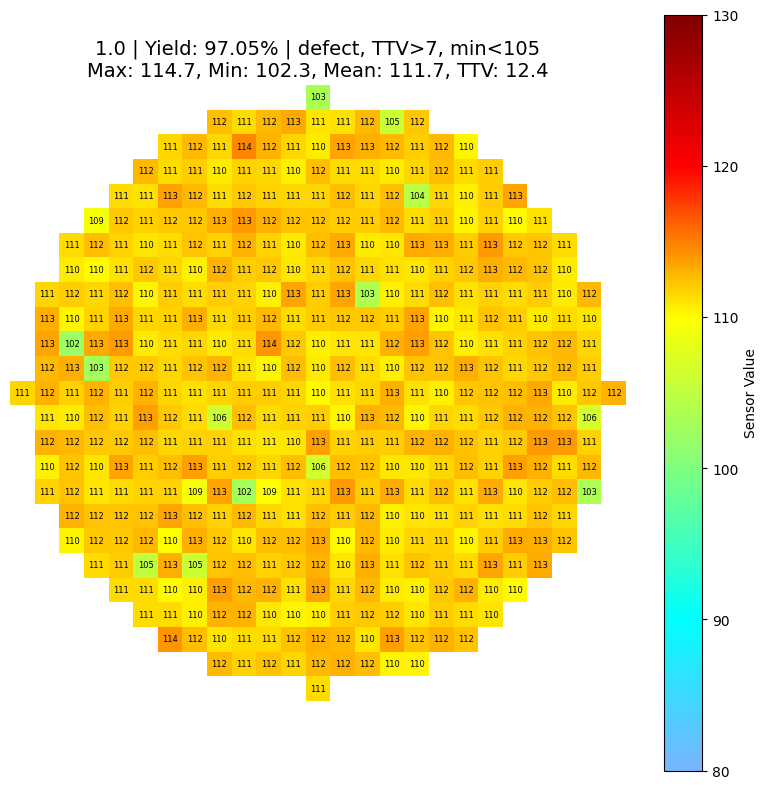

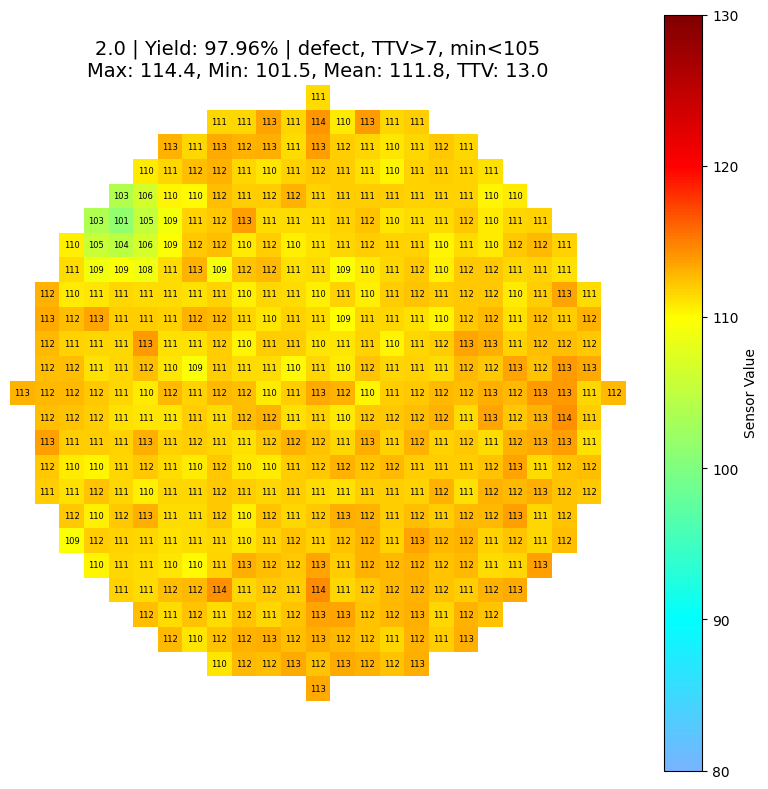

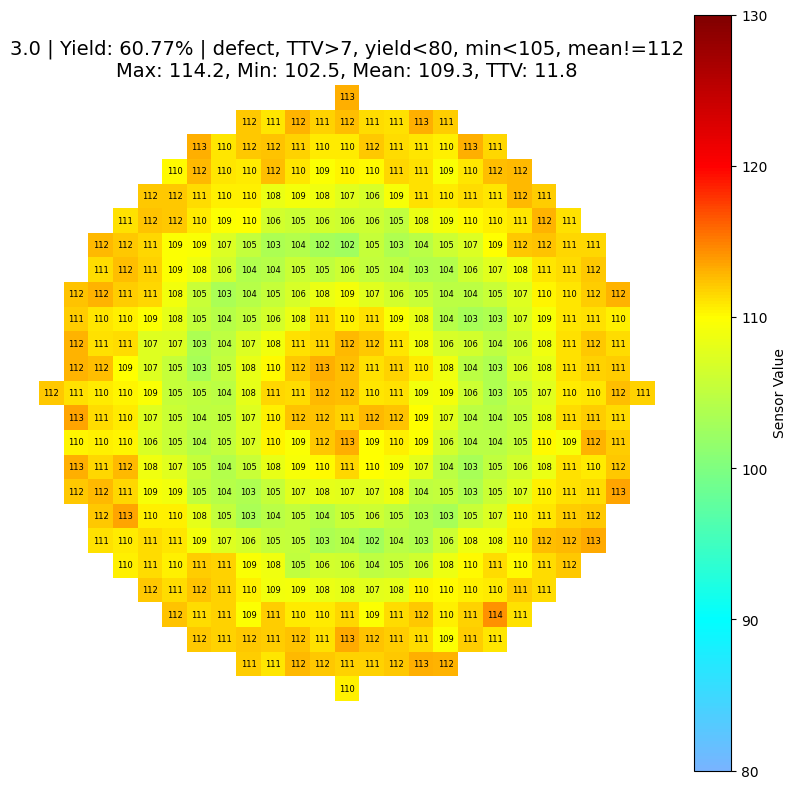

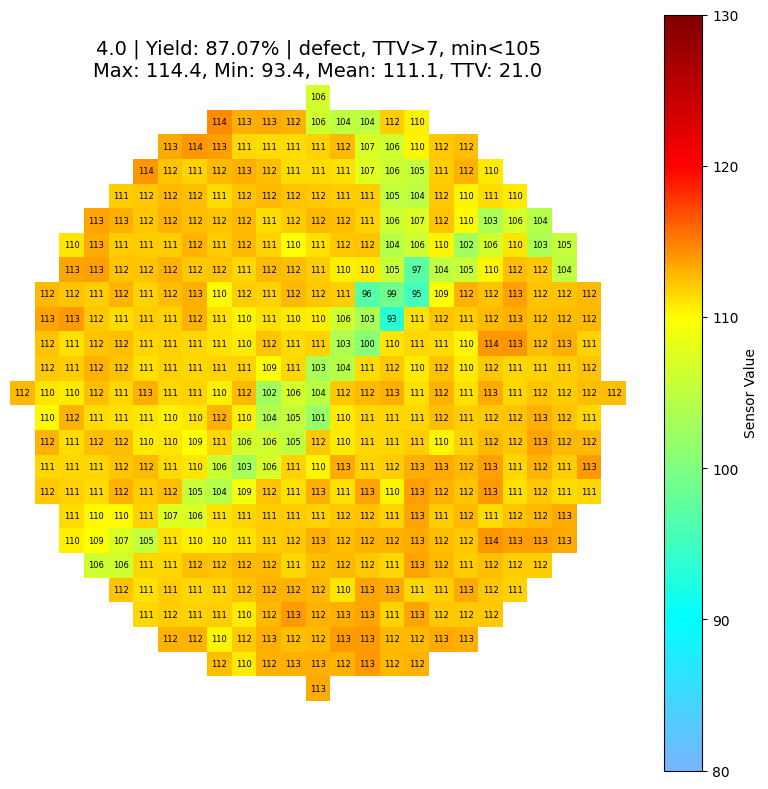

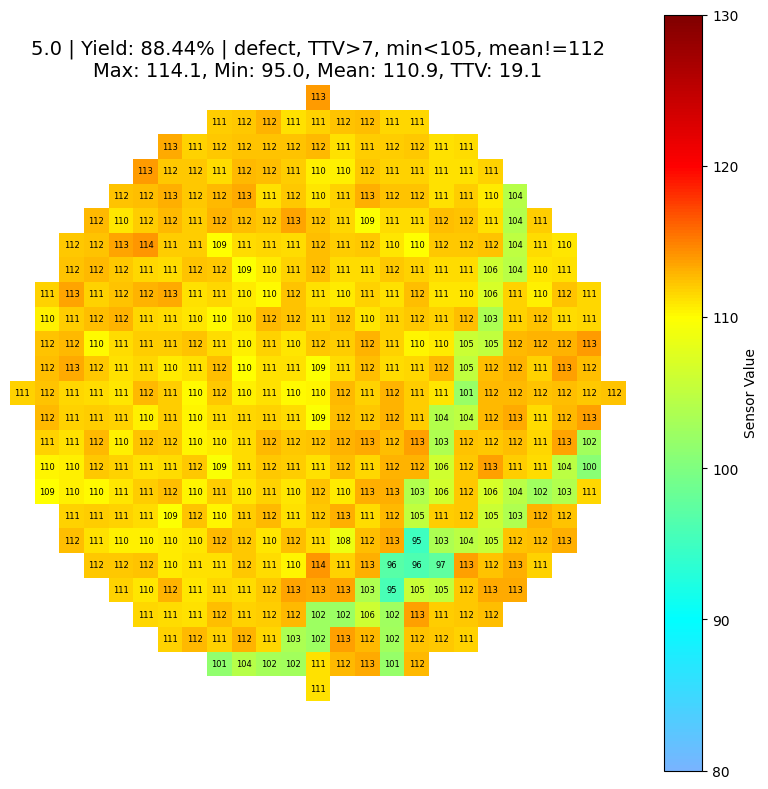

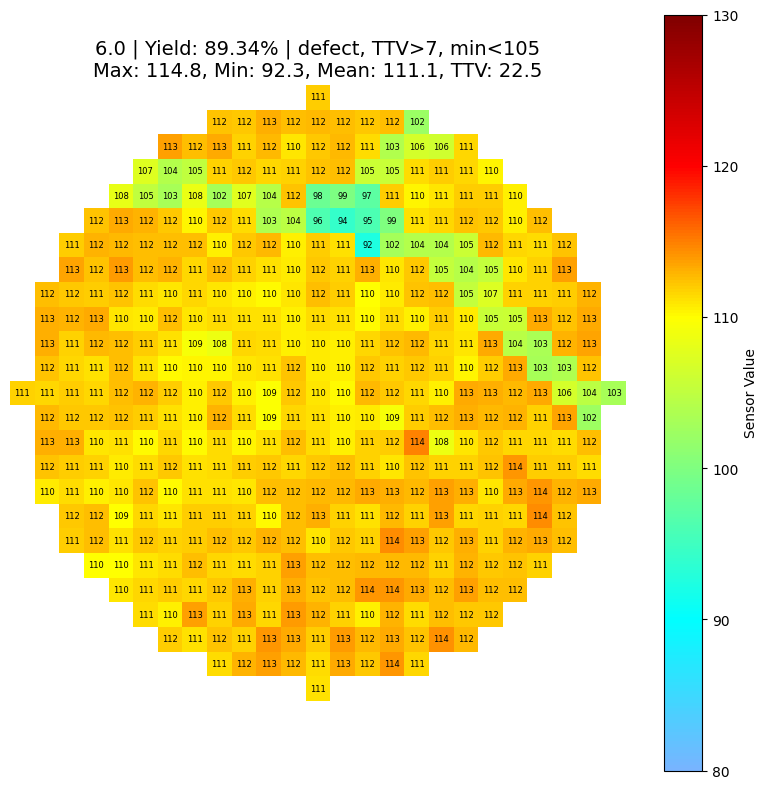

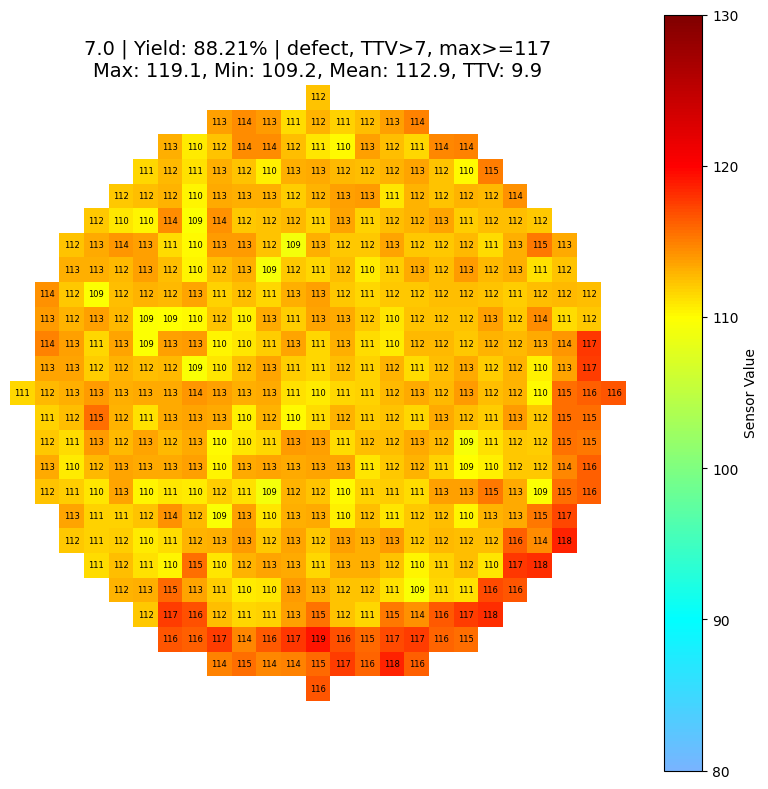

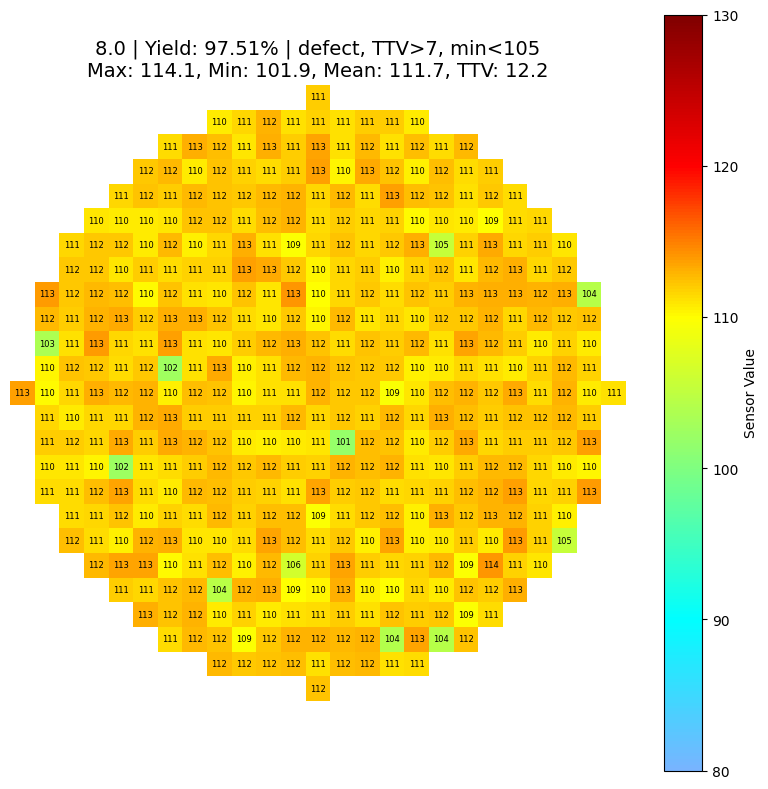

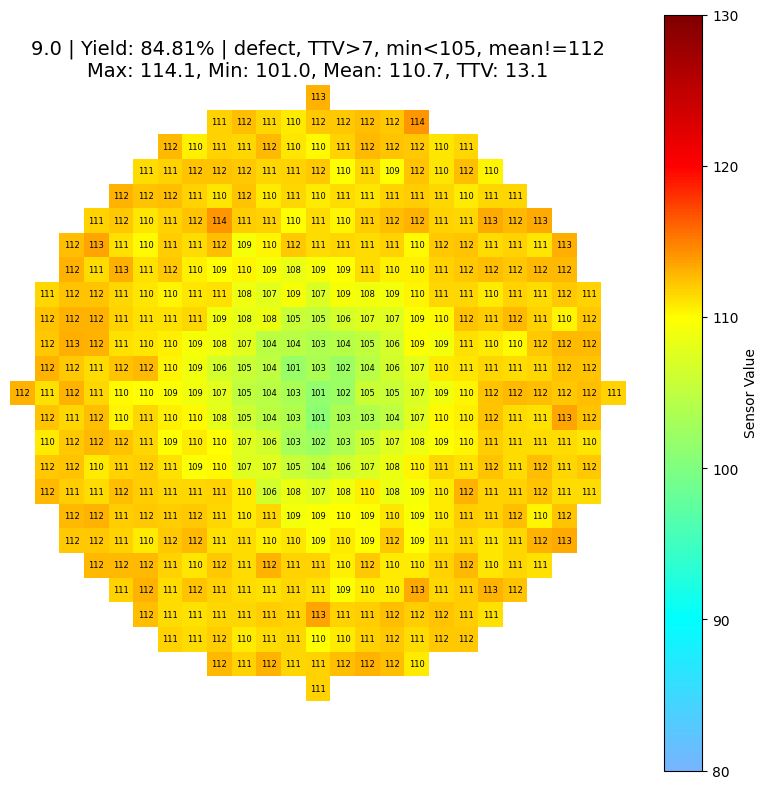

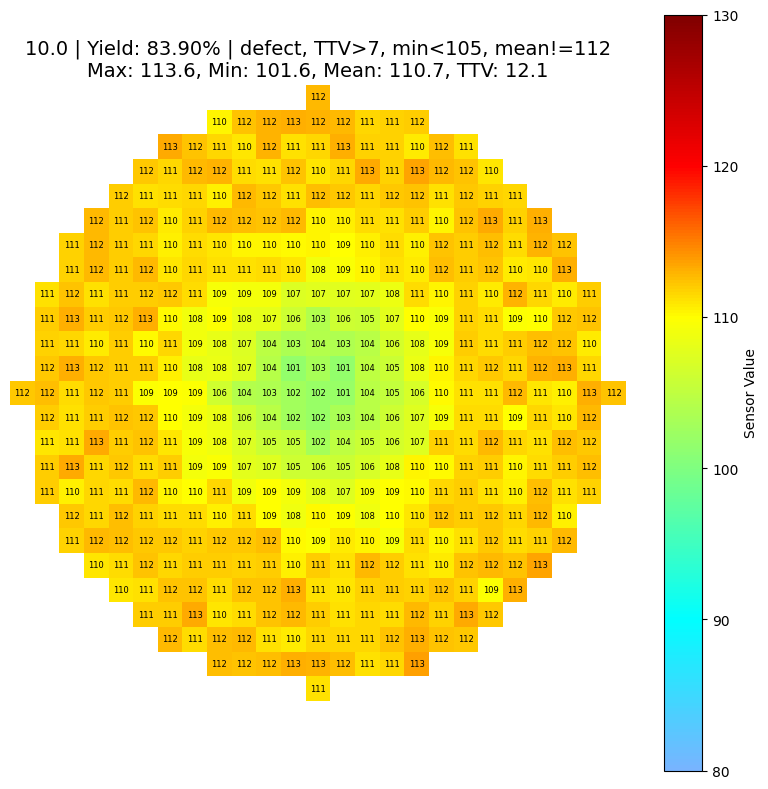

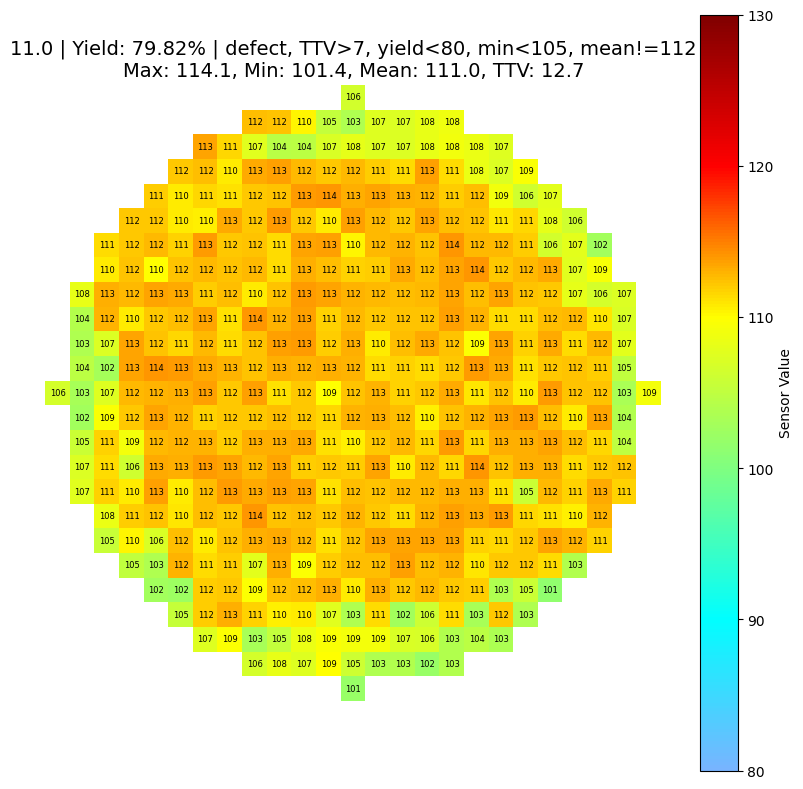

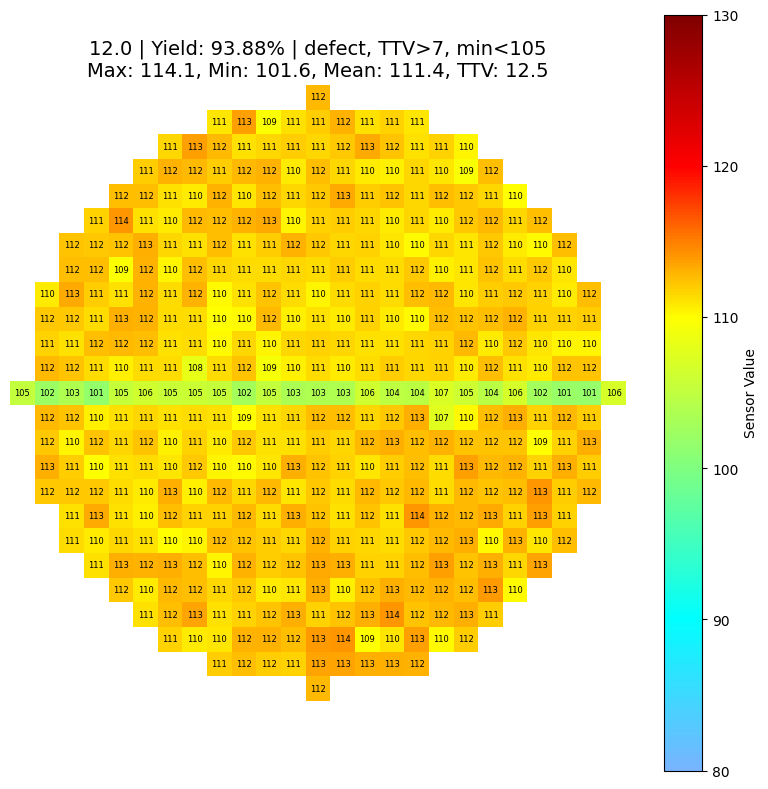

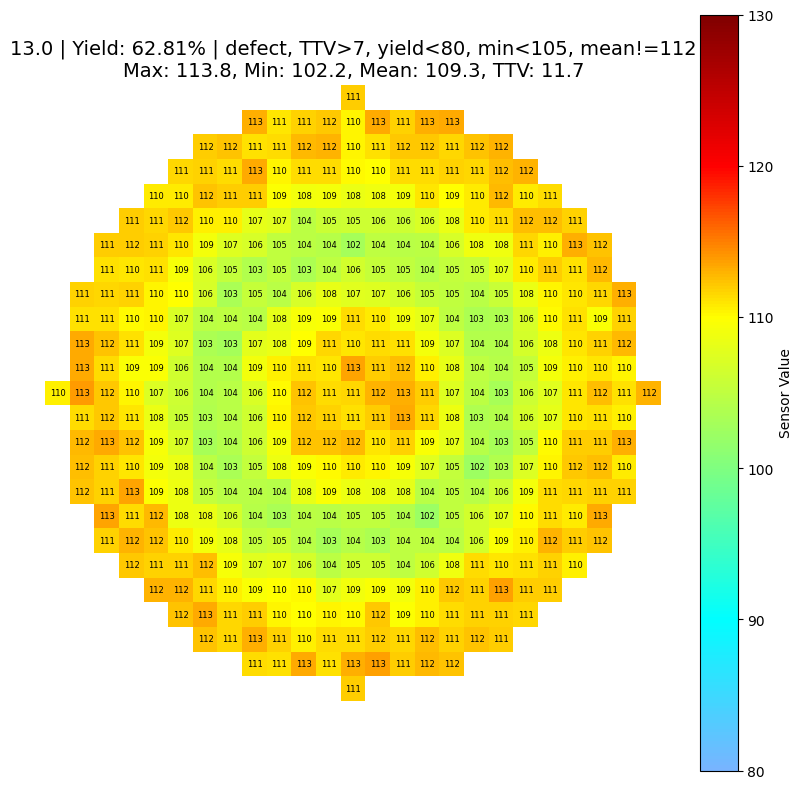

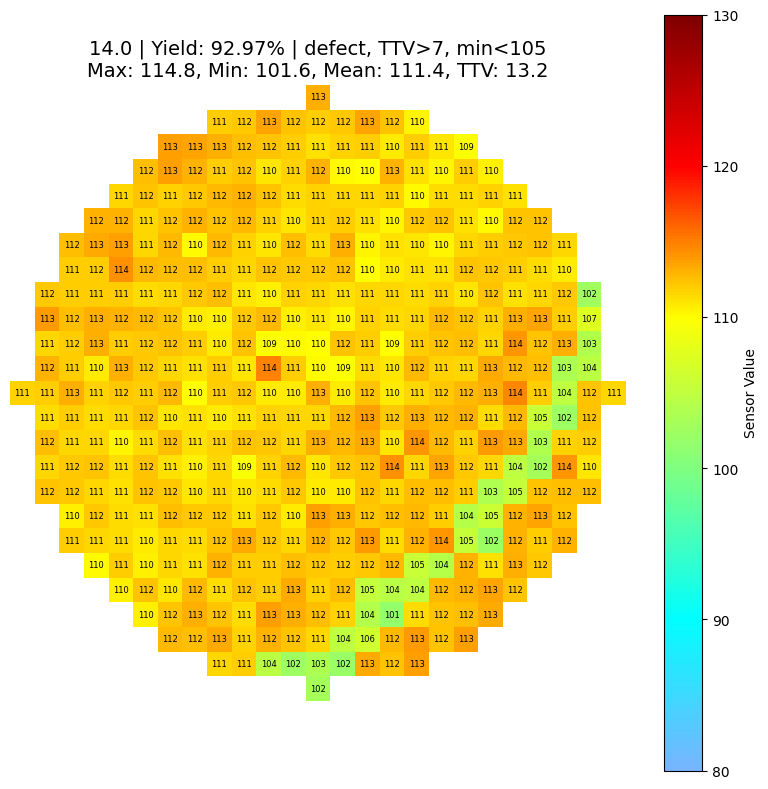

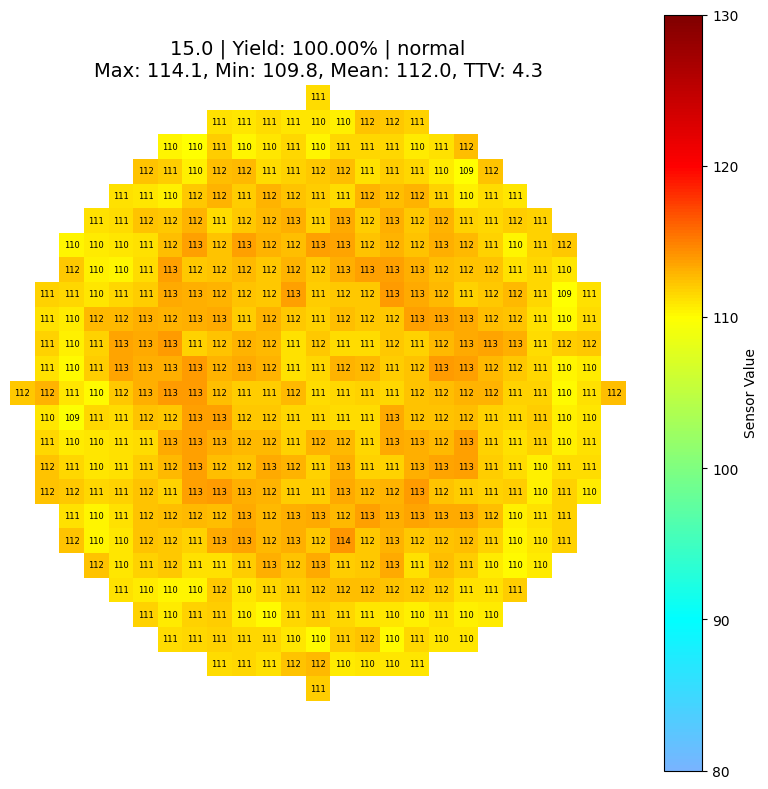

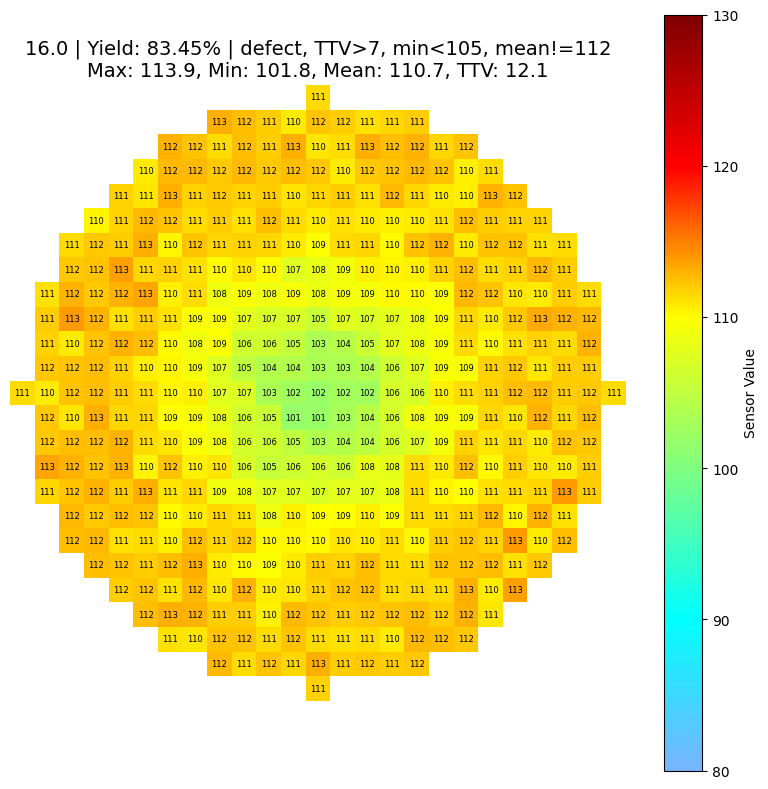

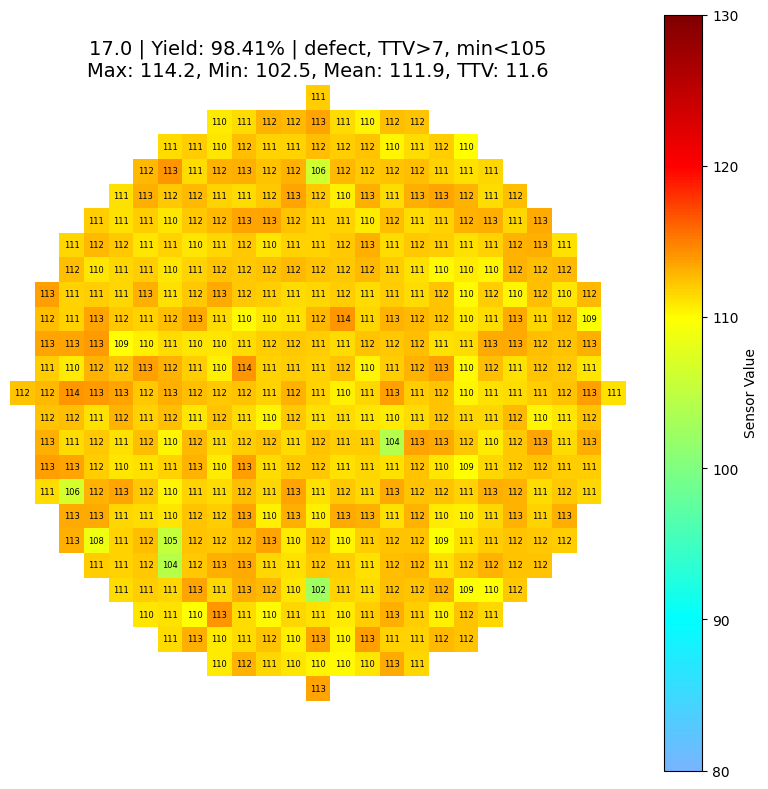

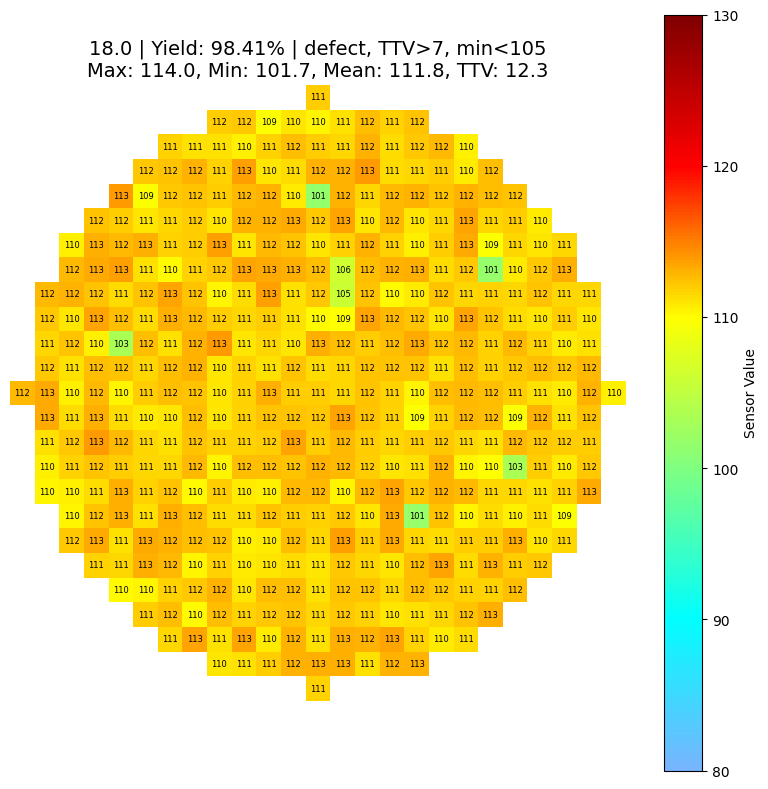

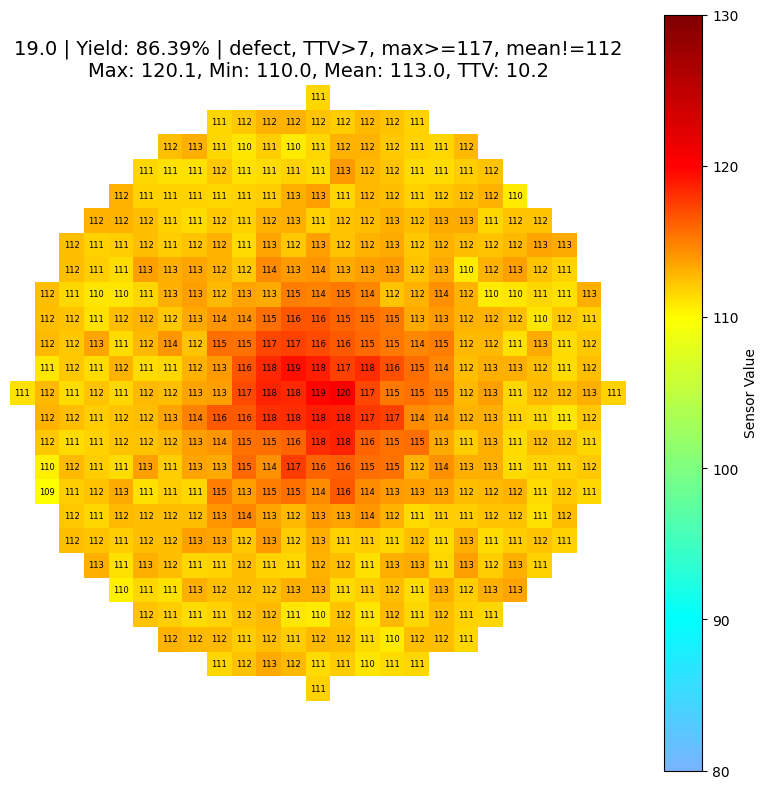

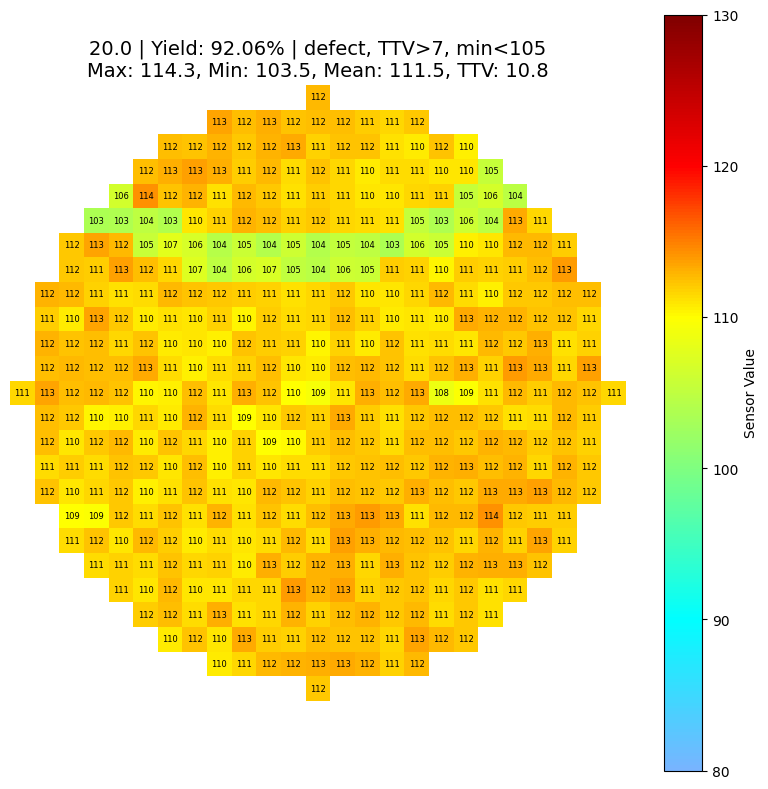

In [44]:
defect_wafer_ids = []

for idx, row in df.iterrows():
    wafer_id = row.get('unnamed: 0', f'Wafer_{idx + 1}')
    sensor_values = pd.to_numeric(row[sensor_cols], errors='coerce').values

    sensor_map = np.full(sensor_shape, np.nan)
    for i, (y, x) in enumerate(final_sorted_coords):
        if i < len(sensor_values):
            sensor_map[y, x] = sensor_values[i]

    normal_sensor = ((sensor_map >= 109) & (sensor_map <= 115))
    normal_count = np.count_nonzero(normal_sensor)
    total_sensor = np.count_nonzero(~np.isnan(sensor_map))
    wafer_yield = normal_count / total_sensor * 100 if total_sensor > 0 else 0

    max_val = np.nanmax(sensor_map)
    min_val = np.nanmin(sensor_map)
    mean_val = np.nanmean(sensor_map)
    ttv = max_val - min_val

    defect_reasons = []
    if ttv > 7:
        defect_reasons.append('TTV>7')
    if wafer_yield < 80:
        defect_reasons.append('yield<80')
    if max_val >= 117:
        defect_reasons.append('max>=117')
    if min_val < 105:
        defect_reasons.append('min<105')
    if mean_val >= 113.0 or mean_val < 111.0:
        defect_reasons.append('mean!=112')

    if defect_reasons:
        defect_label = 'defect, ' + ', '.join(defect_reasons)
    else:
        defect_label = 'normal'

    if defect_label == 'defect':
        defect_wafer_ids.append((wafer_id, defect_label))

    filled_map = fill_nan_with_neighbors(sensor_map, ~mask)
    cmap = LinearSegmentedColormap.from_list('custom', [
        (0, (120/255, 180/255, 255/255)),
        (0.2, (0, 1, 1)),
        (0.4, (0.5, 1, 0.5)),
        (0.6, (1, 1, 0)),
        (0.8, (1, 0, 0)),
        (1.0, (0.5, 0, 0))
    ])

    plt.figure(figsize=(8, 8))
    im = plt.imshow(np.ma.masked_where(~mask, filled_map), cmap=cmap, vmin=80, vmax=130)
    plt.axis('off') # 축을 꺼서 깔끔하게 만듬

    # for i in range(rows):
    #     for j in range(cols):
    #         if mask[i, j]:
    #             val = sensor_map[i, j]
    #             text_color = 'blue' if np.isnan(val) else 'black'
    #             text_val = f'{filled_map[i, j]:.0f}' if np.isnan(val) else f'{int(val)}'
    #             plt.text(j, i, text_val, ha='center', va='center', fontsize=6, color=text_color)

    # 2. 텍스트 정보가 없는 "깔끔한" 이미지를 먼저 저장
    # 저장할 폴더를 새로 지정하여 기존 파일과 섞이지 않게 합니다.
    output_dir = 'test3' # 'wafer_images'
    os.makedirs(output_dir, exist_ok=True)
    wafer_id_csv = row.iloc[0]
    filename = f'{wafer_id_csv}.png' # f'{idx + 1}.png'
    # dpi=300으로 고해상도 이미지 저장
    # bbox_inches='tight'로 이미지 주변의 불필요한 공백 제거
    # pad_inches=0으로 이미지 주변의 여백 제거
    plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches='tight', pad_inches=0)

    title = (
        f'{wafer_id_csv} | Yield: {wafer_yield:.2f}% | {defect_label}\n'
        f'Max: {max_val:.1f}, Min: {min_val:.1f}, Mean: {mean_val:.1f}, TTV: {ttv:.1f}'
    )
    plt.title(title, fontsize=14)
    plt.colorbar(im, label='Sensor Value')

    for i in range(rows):
        for j in range(cols):
            if mask[i, j]:
                val = sensor_map[i, j]
                text_color = 'blue' if np.isnan(val) else 'black'
                text_val = f'{filled_map[i, j]:.0f}' if np.isnan(val) else f'{int(val)}'
                plt.text(j, i, text_val, ha='center', va='center', fontsize=6, color=text_color)

    plt.tight_layout()
    plt.show()